# Applied Machine Learning Experiment: Linear Regression with One Feature

**Author:** Dorsa Norouzi  
**Project Type:** Portfolio Demo / Machine Learning Practice  
**Year:** 2026

## Project Overview

This notebook implements a simple linear regression workflow for predicting food-truck profit from city population. The project demonstrates the core mechanics of regression by implementing the hypothesis function, mean-squared-error cost, gradient calculation, gradient descent optimization, prediction, and a comparison with scikit-learn's `LinearRegression` model.

## What This Notebook Demonstrates

- Linear regression with one input feature
- Cost-function implementation from core NumPy operations
- Batch gradient descent and convergence monitoring
- Prediction using learned model parameters
- Comparison between a from-scratch implementation and scikit-learn


In [1]:
%matplotlib inline

import sys
sys.path.insert(0, 'labutils/')

try:
    from lab2utils import lab2partB1
    lab2B1 = lab2partB1()
except Exception:
    class _NoOpPlot:
        def plot(self, *args, **kwargs):
            pass
    lab2B1 = _NoOpPlot()


## 1. Dataset and Objective

The dataset contains two columns: city population and food-truck profit. The objective is to learn a linear relationship between population and profit, then use the fitted model to estimate profit for new city sizes.


In [2]:
import numpy as np

# Loading the data from the file into mydata
filename = "datasets/PopulationProfit.csv"
mydata = np.genfromtxt(filename, delimiter=",")

# We have n cities (each line corresponds to one city)
n = len(mydata)

# We take the population values from mydata and reshape it into a matrix X of n
# lines and 1 column (population), i.e. an array of n 1-dimensional feature-vectors
X = mydata[:, 0].reshape(n, 1)

# We take the profit values from mydata (-1 refers to the last column). So,
# y is the vector of outputs (profits), i.e. an array of n scalar values
y = mydata[:, -1]


print(X[:10])
print(y[:10])


[[6.1101]
 [5.5277]
 [8.5186]
 [7.0032]
 [5.8598]
 [8.3829]
 [7.4764]
 [8.5781]
 [6.4862]
 [5.0546]]
[17.592   9.1302 13.662  11.854   6.8233 11.886   4.3483 12.      6.5987
  3.8166]


## 2. Exploratory Visualization

A scatter plot is used to inspect the relationship between population and profit before model training.


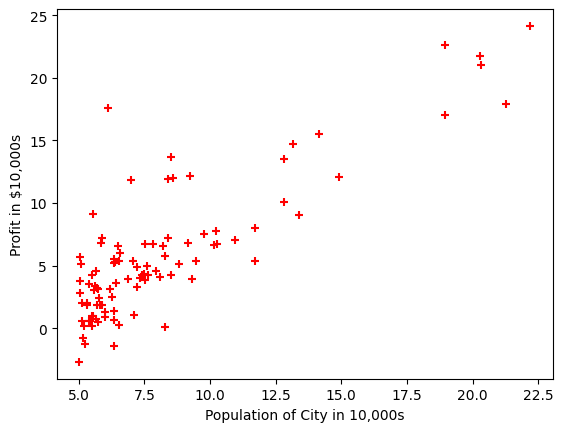

In [3]:
import matplotlib.pylab as plt

# We get the list of values of the 1st feature (column 0 from X) as follows
population = X[:, 0] # take the values at "all lines" and "column 0"


fig, ax = plt.subplots()
ax.scatter(X[:,0],y[:],color = "red",marker = "+")
ax.set_xlabel("Population of City in 10,000s")
ax.set_ylabel("Profit in $10,000s")
plt.show()


## 3. Linear Regression from Scratch

The regression model is trained by minimizing the mean-squared-error cost function. An intercept column is added to the input matrix so the model can learn both the bias term and the feature weight.

The model follows the standard linear form:

$$h_\theta(x) = \theta^T x = \theta_0 + \theta_1 x_1$$


In [ ]:
def add_all_ones_column(X):
    n, d = X.shape # dimension of the matrix X (n lines, d columns)
    XX = np.ones((n, d+1)) # new matrix of all ones with one additional column
    XX[:, 1:] = X # set X starting from column 1 (keep only column 0 unchanged)
    return XX

# The following line creates a new data matrix with an additional first column (of ones)
X_new = add_all_ones_column(X)


print(X_new[0:10,:])


[[1.     6.1101]
 [1.     5.5277]
 [1.     8.5186]
 [1.     7.0032]
 [1.     5.8598]
 [1.     8.3829]
 [1.     7.4764]
 [1.     8.5781]
 [1.     6.4862]
 [1.     5.0546]]


## 4. Cost Function

The cost function measures how far the predicted values are from the true profit values. It is used to monitor whether gradient descent is converging.


In [ ]:
def h(theta, x):
    return x @ theta



import numpy as np

def E(theta, X, y):
    n = len(y)
    error = y - h(theta,X)
    return np.sum(error**2) / (2 * n)


theta = np.array([0, 0])
print("Initial cost: ", E(theta, X_new, y)) 


Initial cost:  32.072733877455676


## 5. Gradient Computation

The gradient of the cost function is computed with respect to each model parameter. This gradient is then used to update the parameters during training.


In [ ]:
def gradE(theta, X, y):
    n = len(y)
    error = X @ theta - y
    gradient = (1 / n) * (X.T @ error)
    return gradient


theta = np.array([0, 0])
print("Test: ", gradE(theta, X_new, y)) 


Test:  [ -5.83913505 -65.32884975]


## 6. Gradient Descent Training

Batch gradient descent iteratively updates the parameter vector until the cost decreases and stabilizes.


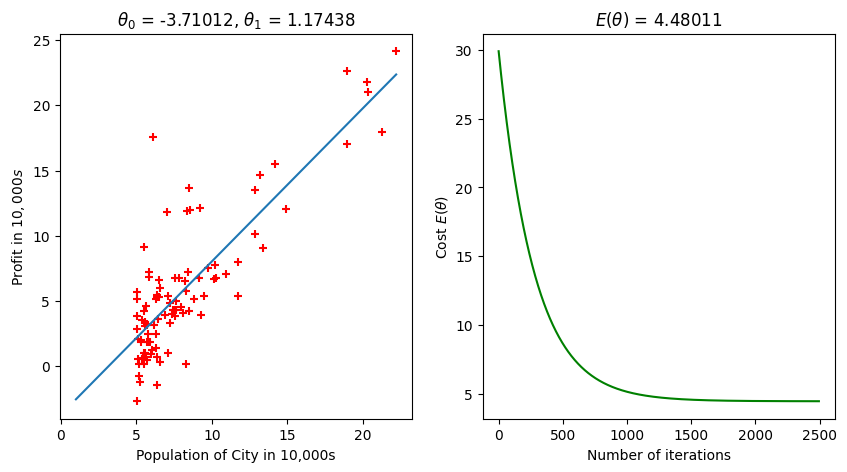

In [55]:
alpha = 0.01                     # The learning rate of gradient descent
theta = np.array([10, -30])      # Some initial parameters vector: theta = [theta_0, theta_1, ...]
max_iterations = 5000            # Maximum number of iterations
epsilon = 0.00001                # Some small number to test for convergence (i.e. to stop if F(a) does not decrease too much)

for itr in range(max_iterations):
    prev = E(theta, X_new, y) # Save the value of E(theta)



    theta = theta - alpha * gradE(theta, X_new, y)


    CONDITION = abs(prev - E(theta, X_new,y)) < epsilon # Replace True with a boolean condition
    if CONDITION:
        break


## 7. Predictions

After training, the learned model is used to predict profit for two new city population values: 35,000 and 70,000 people.


In [56]:
# prediction1 =
X_pred1 = np.array([1,3.5])
prediction1 = np.dot(theta, X_pred1)
# prediction2 = ...
X_pred2 = np.array([1,7])
prediction2 = np.dot(theta, X_pred2)

print(prediction1, prediction2)


0.39284854340918196 4.507181347895143


## 8. Comparison with scikit-learn

A scikit-learn `LinearRegression` model is trained on the same dataset to compare the library-based solution with the from-scratch NumPy implementation.


In [57]:
# Import the LinearRegression class
from sklearn.linear_model import LinearRegression

"""
Instantiate a LinearRegression() model and train it by calling fit on the training
data (input data X and outputs y). Note that we use the original data X, we
don't need to add a column of ones to X. Scikit-learn takes care of such details.
"""
reg = LinearRegression().fit(X, y) # Training


## 9. Parameter Comparison

The intercept and coefficient learned by the custom implementation are compared with the values learned by scikit-learn.


In [58]:
print("theta_0 learned using your initial code: ", theta[0])
print("theta_0 learned using sklearn: ", reg.intercept_)
print()
print("prameters [theta_1, ...] learned using your initial code: ", theta[1:]) # starting from theta_1
print("prameters [theta_1, ...] learned using sklearn: ", reg.coef_)


theta_0 learned using your initial code:  -3.7214842610767795
theta_0 learned using sklearn:  -3.895780878311852

prameters [theta_1, ...] learned using your initial code:  [1.17552366]
prameters [theta_1, ...] learned using sklearn:  [1.19303364]


## 10. scikit-learn Predictions

The trained scikit-learn model is used to generate predictions for the same new population values.


In [59]:
# Our test data is:
X_test = np.array([
    [3.5], # first data-point
    [7]    # second data-point
])

# Now we can predict the outputs simply using:
y_pred = reg.predict(X_test)
print( y_pred )

# These predictions should be similar (close enough) to what you got with your own code previously.


[0.27983688 4.45545463]


## 11. Summary

This experiment demonstrates the complete basic regression workflow: data loading, visualization, cost-function implementation, gradient descent, prediction, and comparison with a standard machine-learning library.
